# Models & automatic fitting

The studies behind dtfit concluded that *picking the structurally-correct model
is the whole game*. `dtfit.models` makes that ergonomic: a catalog of named,
**self-seeding** families (they read `p0` / `bounds` off the data), composition
with `+`, and a recommender that ranks families by AIC.

In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

# Fitting at extreme parameter trials can overflow exp() harmlessly; keep the
# guide output clean.
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
rng = np.random.default_rng(0)

## The catalog

`CATALOG` maps a name to a family factory, grouped by `category`.

In [2]:
from collections import defaultdict
from dtfit.models import CATALOG

by_cat = defaultdict(list)
for name, factory in CATALOG.items():
    by_cat[factory().category].append(name)
for cat, names in by_cat.items():
    print(f"{cat:11s}: {', '.join(names)}")

trend      : linear, quadratic, cubic, power_law, logarithmic, sqrt_law
growth     : exponential, exp_growth_offset
decay      : exp_decay, exp_decay_offset, first_order, biexponential, stretched_exponential
sigmoid    : logistic, gompertz, weibull_cdf, tanh_step
saturating : michaelis_menten, hill
peak       : gaussian, lorentzian, double_gaussian
oscillatory: sine, damped_oscillation


## Self-seeding fit - no `p0` needed

Each family reads sensible initial values and bounds off the data, then fits
through the stable engines (routing via `auto_estimate`).

FittingResult: L/(1 + exp(-k*(x - x0)))
  L = 7.99263 +/- 0.0206
  k = 0.887082 +/- 0.00711
  x0 = 4.98896 +/- 0.0114


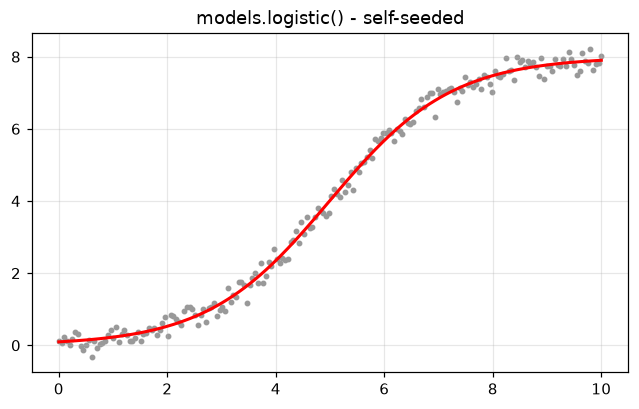

In [3]:
from dtfit import models

x = np.linspace(0, 10, 200)
y = 8.0 / (1 + np.exp(-0.9 * (x - 5))) + rng.normal(0, 0.2, x.size)

fit = models.logistic().fit(x, y)        # no p0 / bounds supplied
print(fit.summary())

plt.scatter(x, y, s=8, color="0.6")
plt.plot(x, fit.predict(x), "r-", lw=2)
plt.title("models.logistic() - self-seeded"); plt.show()

## Composition with `+`

Add families to build structure (trend + cycle, a sum of peaks). The second
component is seeded on the residual of the first, so the cycle's frequency and
amplitude are read off the detrended data.

Model('linear+sine', expr='(a0 + a1*x) + (A*sin(p + w*x) + c)', shape='composite')


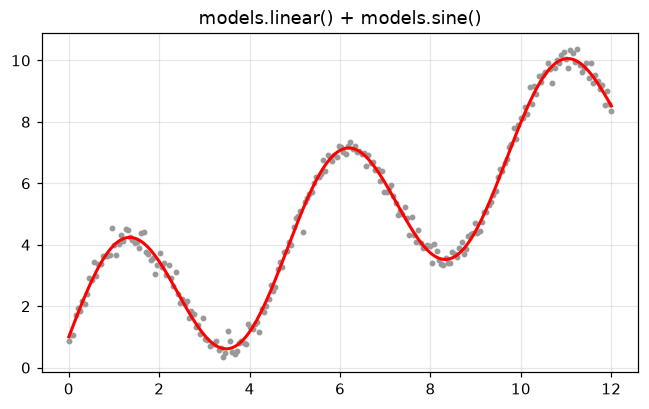

In [4]:
x = np.linspace(0, 12, 240)
y = (1.0 + 0.6 * x) + 2.5 * np.sin(1.3 * x) + rng.normal(0, 0.2, x.size)

model = models.linear() + models.sine()
print(model)
fit = model.fit(x, y)

plt.scatter(x, y, s=8, color="0.6")
plt.plot(x, fit.predict(x), "r-", lw=2)
plt.title("models.linear() + models.sine()"); plt.show()

## Which family? - `suggest_models`

Fits a shape-based shortlist of the catalog and ranks them best-first by AIC.
Each `Suggestion` carries the fitted `Model`, its `FittingResult` and the full
`report`.

double_gaussian           r2=0.9985   aic= -1282.5
gaussian                  r2=0.9983   aic= -1265.0
quadratic                 r2=0.5217   aic=  -134.8
cubic                     r2=0.5217   aic=  -132.8
lorentzian                r2=0.3000   aic=   -58.7


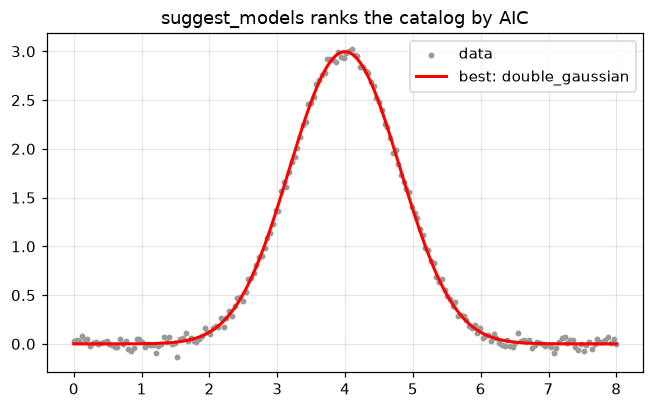

In [5]:
from dtfit import suggest_models

x = np.linspace(0, 8, 200)
y = 3.0 * np.exp(-((x - 4.0) ** 2) / (2 * 0.8 ** 2)) + rng.normal(0, 0.04, x.size)

ranked = suggest_models(x, y, top=5)
for s in ranked:
    print(f"{s.name:24s}  r2={s.r2:.4f}   aic={s.aic:8.1f}")

best = ranked[0]
plt.scatter(x, y, s=8, color="0.6", label="data")
plt.plot(x, best.result.predict(x), "r-", lw=2, label=f"best: {best.name}")
plt.legend(); plt.title("suggest_models ranks the catalog by AIC"); plt.show()

## `auto_estimate` - route by shape

Detects oscillation, transients, peaks and outliers and dispatches to the
estimator variant the parameter-estimation study validated for each.

In [6]:
from dtfit import auto_estimate

x = np.linspace(0, 10, 300)
y = 1.5 * np.sin(2.1 * x) + rng.normal(0, 0.1, x.size)
res = auto_estimate(x, y, "A*sin(w*x)", "x", freq_param="w")   # oscillatory route
print("recovered:", {k: round(v, 3) for k, v in res.params.items()})

recovered: {'A': 1.505, 'w': 2.099}


## `auto_forecast` - fit then extrapolate

Routes the model class (saturating growth -> logistic, a detected cycle ->
linear+seasonal, else a quadratic level) with guards that fall back to
persistence on a near-random-walk series and drop a runaway quadratic to linear.

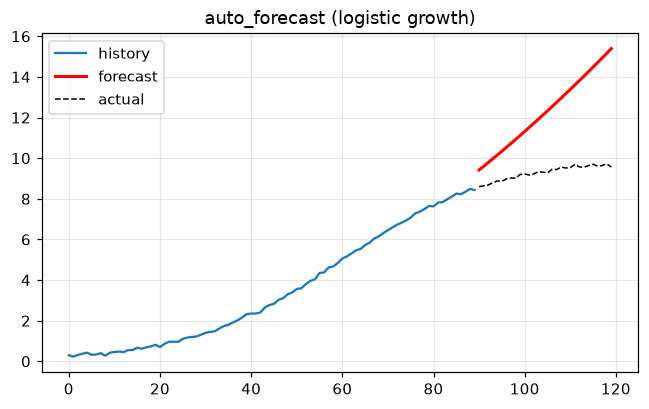

In [7]:
from dtfit import auto_forecast

t = np.arange(120)
series = 10.0 / (1 + np.exp(-0.06 * (t - 60))) + rng.normal(0, 0.05, t.size)
cut, h = 90, 30
fc = auto_forecast(t[:cut], series[:cut], horizon=h)

plt.plot(t[:cut], series[:cut], label="history")
plt.plot(np.arange(cut, cut + h), fc, "r-", lw=2, label="forecast")
plt.plot(np.arange(cut, 120), series[cut:120], "k--", lw=1, label="actual")
plt.legend(); plt.title("auto_forecast (logistic growth)"); plt.show()